# Results analysis

## Configuration

Everything below reads from `results/`. No GPU, no model loading.

In [23]:
# ---- what to analyse ------------------------------------------------------ #
MODEL   = "Qwen3.5-2B"        # "Qwen3.5-2B" | "Qwen3.5-0.8B" | "LFM2.5-350M"
SUBSET  = "all"               # "all" | "has_description" | "no_description"
MAIN    = "hit@3"             # metric of the tables and plots below: "hit@1" | "hit@3" | "hit@5"
RANKING = "ranked_ids"        # "ranked_ids" (pool of 8) | "open_ranked" (all 5,014 pictograms)
METRICS = ["hit@1", "hit@3", "hit@5", "mrr", "relaxed_hit@1", "relaxed_hit@3", "relaxed_hit@5",
           "relaxed_mrr", "gen_exact"]   # hit@10 makes sense only with open_ranked
# --------------------------------------------------------------------------- #

import json, sys
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd()))
from src.data import load_corpus, NO_DESCRIPTION
from src.metrics import load_predictions, compute, breakdown

RESULTS, FIGURES = Path("results"), Path("figures")
FIGURES.mkdir(exist_ok=True)
pd.set_option("display.width", 200, "display.max_columns", 50)
plt.rcParams.update({"figure.dpi": 120, "font.size": 9, "axes.grid": True,
                     "grid.alpha": .25, "axes.spines.top": False,
                     "axes.spines.right": False})
BLUE, ORANGE, GREEN, GREY = "#4C6EF5", "#F76707", "#37B24D", "#868E96"

corpus = load_corpus()
MODELS = ["LFM2.5-350M", "Qwen3.5-0.8B", "Qwen3.5-2B"]

In [25]:
# Names shown for the runs, in this order
LABELS = {
    "baseline_random":        "random pick",
    "baseline_frequency":     "frequency prior",
    "baseline_ngram":         "n-gram + back-off",
    "id":                     "FT  id",
    "text":                   "FT  text",
    "picto_text":             "FT  picto",
    "picto_text_constrained": "FT  picto + constraints",
    "picto_image":            "FT  picto (image init)",
}

def parse(name):
    """'picto_text_Qwen3.5-2B_constrained' -> ('picto_text_constrained', 'Qwen3.5-2B')"""
    for tag in MODELS:
        if f"_{tag}" in name:
            return name.replace(f"_{tag}", "", 1), tag
    return name, None

def load(name):
    f = RESULTS / name / "predictions.jsonl"
    return load_predictions(f) if f.exists() else None

def subset(records, which=SUBSET):
    if which == "has_description":
        return [r for r in records if r.get("has_description")]
    if which == "no_description":
        return [r for r in records if r.get("has_description") is False]
    return records

def runs_for(model=MODEL):
    """Map pretty label -> records: the baselines and the runs of one model, in LABELS order"""
    found = {}
    for d in RESULTS.iterdir():
        key, tag = parse(d.name)
        if key in LABELS and tag in (None, model) and (d / "predictions.jsonl").exists():
            found[key] = load(d.name)
    return {LABELS[k]: found[k] for k in LABELS if k in found}

def results_table(runs, metrics=METRICS, ranking=RANKING, which=SUBSET):
    """Metrics for each run as a DataFrame, with a +/- column per metric"""
    rows = {}
    for label, recs in runs.items():
        m = compute(subset(recs, which), corpus.equivalence, k_values=(1, 3, 5, 10), rank_key=ranking)
        if not m.get("n"):
            continue
        row = {"n": m["n"]}
        for k in metrics:
            if k in m:
                row[k] = round(m[k], 3)
                ci = m.get(f"{k}_ci")
                row[f"{k} ±"] = round((ci[1] - ci[0]) / 2, 3) if ci else np.nan
        rows[label] = row
    return pd.DataFrame(rows).T

RUNS = runs_for()
print(f"{len(RUNS)} runs loaded for MODEL={MODEL!r}")

8 runs loaded for MODEL='Qwen3.5-2B'


## 1. Data

54,797 sentences, each an ordered list of pictogram ids, plus metadata and a PNG
for 12,464 pictograms. **13.6 % of the pictograms the model must predict have no
text metadata at all**, which motivates the vision experiment.

In [26]:
cat = corpus.catalogue
sent = pd.concat(corpus.splits.values())
empty = [p for p in corpus.vocab_ids
         if corpus.description.get(p, NO_DESCRIPTION) == NO_DESCRIPTION]

pd.Series({
    "pictograms in the catalogue": len(cat),
    "pictograms with no metadata": int((~cat["has_metadata"]).sum()),
    "sentences used": len(sent),
    "pictograms per sentence (mean)": round(sent["n_pictos"].mean(), 2),
    "decision steps": sum(len(v) for v in corpus.steps.values()),
    "label space": len(corpus.vocab_ids),
    "label space with no description": len(empty),
}, dtype=object).to_frame("value")

,value
pictograms in the catalogue,12464
pictograms with no metadata,1807
sentences used,15500
pictograms per sentence (mean),4.2
decision steps,65026
label space,5014
label space with no description,681


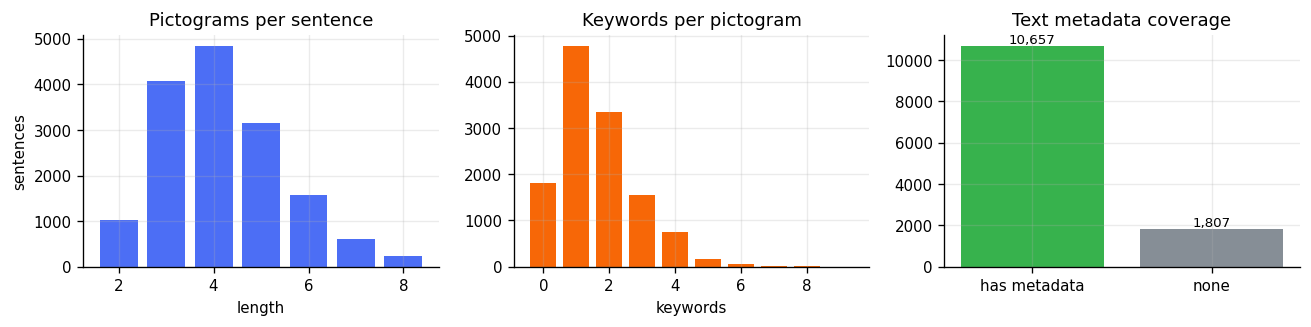

In [27]:
fig, ax = plt.subplots(1, 3, figsize=(11, 2.8))
c = sent["n_pictos"].value_counts().sort_index()
ax[0].bar(c.index, c.values, color=BLUE)
ax[0].set(title="Pictograms per sentence", xlabel="length", ylabel="sentences")

ax[1].hist(cat["keywords"].apply(len), bins=range(0, 11), color=ORANGE, align="left", rwidth=.8)
ax[1].set(title="Keywords per pictogram", xlabel="keywords")

has = cat["has_metadata"].value_counts()
ax[2].bar(["has metadata", "none"], [has.get(True, 0), has.get(False, 0)], color=[GREEN, GREY])
ax[2].set(title="Text metadata coverage")
for i, v in enumerate([has.get(True, 0), has.get(False, 0)]):
    ax[2].text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=8)

plt.tight_layout(); plt.savefig(FIGURES / "01_data.png", bbox_inches="tight"); plt.show()

## 2. Candidate pools

Each step offers 8 candidates: the pictograms the sentence still needs (the gold
and the later ones) plus distractors retrieved with TF-IDF against the sentence.
With random distractors the baselines score higher without reading anything;
the retrieval pool removes that shortcut.

In [28]:
comp = {}
for regime, path in [("retrieval negatives", "baselines.json"),
                     ("random negatives", "baselines_random.json")]:
    for name, m in json.loads((RESULTS / path).read_text()).items():
        comp.setdefault(name, {})[regime] = round(m[MAIN], 3)
pd.DataFrame(comp).T.rename_axis(f"baseline ({MAIN})")

,retrieval negatives,random negatives
baseline (hit@3),,
random,0.365,0.376
frequency,0.774,0.823
ngram,0.782,0.830


## 3. The three output representations

One test step: strawberry and heart are already chosen, the next pictogram is
love. `id` and `text` get the same prompt and differ only in the target; `picto`
has no candidate list and sees the chosen pictograms as tokens.

In [29]:
from src.prompts import build_prompt, build_target, system_prompt, MODES
step = next(s for s in corpus.steps["test"] if s["step_id"] == "739:2")
for mode in MODES:
    print(f"--- {mode}")
    print(system_prompt(mode, include_sentence=False))
    print(build_prompt(step, corpus, mode))
    print("target:", build_target(step, corpus, mode))
    print()

--- id
You help build sentences with ARASAAC pictograms. Given the pictograms already chosen and a list of candidates, reply with the id of the next pictogram. Reply with the id only.
Selected: strawberry (fruit, core vocabulary-feeding) | heart (shape, core vocabulary-object)
Candidates:
4763 triangle (shape, geometry)
2715 heart (human anatomy, circulatory system)
2470 jam, strawberry jam (ultra-processed food)
11178 love, sweetheart, beloved (feeling)
37733 spiral (shape, geometry)
5490 heart attack (disease)
4644 star (shape)
4761 trapezoid (shape)
Next:
target: 11178

--- text
You help build sentences with ARASAAC pictograms. Given the pictograms already chosen and a list of candidates, reply with the description of the next pictogram. Reply with the description only.
Selected: strawberry (fruit, core vocabulary-feeding) | heart (shape, core vocabulary-object)
Candidates:
4763 triangle (shape, geometry)
2715 heart (human anatomy, circulatory system)
2470 jam, strawberry jam (ultra

In [30]:
# What each run ranks first, second and third on this step
first3 = {}
for label, recs in RUNS.items():
    r = next(r for r in recs if r["step_id"] == step["step_id"])
    first3[label] = [corpus.description[p].split(" (")[0] for p in r["ranked_ids"][:3]]
pd.DataFrame(first3, index=["1st", "2nd", "3rd"]).T

,1st,2nd,3rd
random pick,triangle,heart attack,spiral
frequency prior,"love, sweetheart, beloved",star,triangle
n-gram + back-off,"love, sweetheart, beloved",star,triangle
FT id,"love, sweetheart, beloved",spiral,triangle
FT text,"love, sweetheart, beloved",heart,"jam, strawberry jam"
FT picto,"love, sweetheart, beloved",star,heart attack
FT picto + constraints,"love, sweetheart, beloved",star,heart attack
FT picto (image init),"love, sweetheart, beloved",star,triangle


## 4. Results

Pool of 8, 8,467 test decisions, 95 % Wilson intervals. `strict` requires the
exact gold pictogram; `relaxed` accepts any pictogram sharing a keyword with it.

In [31]:
# gen_exact: share of steps where the free generation is exactly right; "-" for the
# baselines, which do not generate
TABLE = results_table(RUNS)
TABLE.fillna("-")

,n,hit@1,hit@1 ±,hit@3,hit@3 ±,hit@5,hit@5 ±,mrr,mrr ±,relaxed_hit@1,relaxed_hit@1 ±,relaxed_hit@3,relaxed_hit@3 ±,relaxed_hit@5,relaxed_hit@5 ±,relaxed_mrr,relaxed_mrr ±,gen_exact,gen_exact ±
random pick,8467.0,0.121,0.007,0.365,0.010,0.619,0.010,0.335,0.006,0.144,0.007,0.405,0.010,0.655,0.010,0.360,0.006,-,-
frequency prior,8467.0,0.379,0.010,0.774,0.009,0.940,0.005,0.597,0.007,0.389,0.010,0.786,0.009,0.944,0.005,0.606,0.007,-,-
n-gram + back-off,8467.0,0.387,0.010,0.782,0.009,0.941,0.005,0.603,0.007,0.398,0.010,0.793,0.009,0.944,0.005,0.613,0.007,-,-
FT id,8467.0,0.508,0.011,0.867,0.007,0.969,0.004,0.696,0.007,0.518,0.011,0.880,0.007,0.975,0.003,0.705,0.007,0.496,0.011
FT text,8467.0,0.472,0.011,0.815,0.008,0.933,0.005,0.660,0.007,0.487,0.011,0.827,0.008,0.939,0.005,0.672,0.007,0.369,0.01
FT picto,8467.0,0.392,0.010,0.785,0.009,0.946,0.005,0.607,0.007,0.404,0.010,0.794,0.009,0.948,0.005,0.616,0.007,0.041,0.004
FT picto + constraints,8467.0,0.398,0.010,0.789,0.009,0.947,0.005,0.611,0.007,0.410,0.010,0.798,0.009,0.949,0.005,0.621,0.007,0.041,0.004
FT picto (image init),8467.0,0.401,0.010,0.799,0.009,0.955,0.004,0.617,0.007,0.413,0.010,0.808,0.008,0.957,0.004,0.626,0.007,0.04,0.004


### 4.1 Three models

`MAIN` for every model and output mode, same data and hyperparameters.

In [32]:
grid = {}
for mode, key in [("id", "id"), ("text", "text"), ("picto", "picto_text")]:
    for tag in MODELS:
        recs = load(f"{key}_{tag}")
        if recs:
            grid.setdefault(mode, {})[tag] = compute(subset(recs), corpus.equivalence)[MAIN]
GRID = pd.DataFrame(grid).T.reindex(columns=MODELS).round(3)
GRID

,LFM2.5-350M,Qwen3.5-0.8B,Qwen3.5-2B
id,0.799,0.861,0.867
text,0.788,0.801,0.815
picto,0.781,0.780,0.785


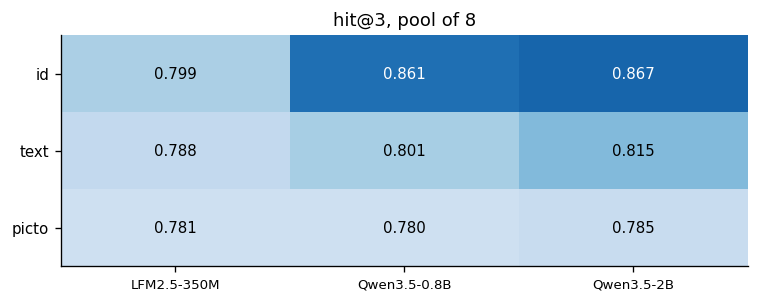

In [33]:
# Heatmap: one cell per (mode, model)
fig, ax = plt.subplots(figsize=(6.4, 2.6))
lo, hi = GRID.values.min() - 0.03, GRID.values.max() + 0.03
im = ax.imshow(GRID.values.astype(float), cmap="Blues", vmin=lo, vmax=hi, aspect="auto")
ax.set_xticks(range(GRID.shape[1]), GRID.columns, fontsize=8)
ax.set_yticks(range(GRID.shape[0]), GRID.index)
ax.grid(False)
for i in range(GRID.shape[0]):
    for j in range(GRID.shape[1]):
        v = GRID.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.3f}", ha="center", va="center",
                    color="white" if v > (lo + hi) / 2 else "black")
ax.set_title(f"{MAIN}, pool of 8")
plt.tight_layout(); plt.savefig(FIGURES / "02_models.png", bbox_inches="tight"); plt.show()

### 4.2 Without a pool: ranking all 5,014 pictograms

`picto` and the frequency / n-gram baselines can rank every pictogram, not only
the 8 candidates. all@k is Hit@k over all 5,014 pictograms: the right one in the
top k. This is where k = 10 makes sense (the pool has only 8). Random would score
k / 5,014.

In [34]:
OPEN = {label: recs for label, recs in RUNS.items() if "open_ranked" in recs[0]}
ALL_K = results_table(OPEN, metrics=["hit@1", "hit@5", "hit@10"], ranking="open_ranked")
ALL_K.rename(columns=lambda c: c.replace("hit@", "all@"))

,n,all@1,all@1 ±,all@5,all@5 ±,all@10,all@10 ±
frequency prior,8467.0,0.013,0.002,0.050,0.005,0.077,0.006
n-gram + back-off,8467.0,0.044,0.004,0.108,0.007,0.149,0.008
FT picto,8467.0,0.042,0.004,0.132,0.007,0.202,0.009
FT picto + constraints,8467.0,0.050,0.005,0.113,0.007,0.151,0.008
FT picto (image init),8467.0,0.041,0.004,0.131,0.007,0.199,0.009


### 4.3 Along the sentence

`MAIN` by position t. At t = 0 nothing has been chosen yet.

In [35]:
rows = {}
for label, recs in RUNS.items():
    b = breakdown(subset(recs), lambda r: min(int(r["t"]), 5), corpus.equivalence)
    rows[label] = {("t=5+" if k == 5 else f"t={k}"): round(v[MAIN], 3) for k, v in sorted(b.items())}
BY_STEP = pd.DataFrame(rows).T
BY_STEP

,t=0,t=1,t=2,t=3,t=4,t=5+
random pick,0.388,0.356,0.351,0.365,0.347,0.389
frequency prior,0.650,0.740,0.803,0.858,0.884,0.913
n-gram + back-off,0.650,0.759,0.815,0.861,0.885,0.915
FT id,0.779,0.829,0.894,0.931,0.955,0.970
FT text,0.701,0.760,0.855,0.903,0.919,0.953
FT picto,0.687,0.754,0.798,0.861,0.886,0.896
FT picto + constraints,0.686,0.760,0.804,0.865,0.889,0.901
FT picto (image init),0.702,0.767,0.814,0.876,0.891,0.918


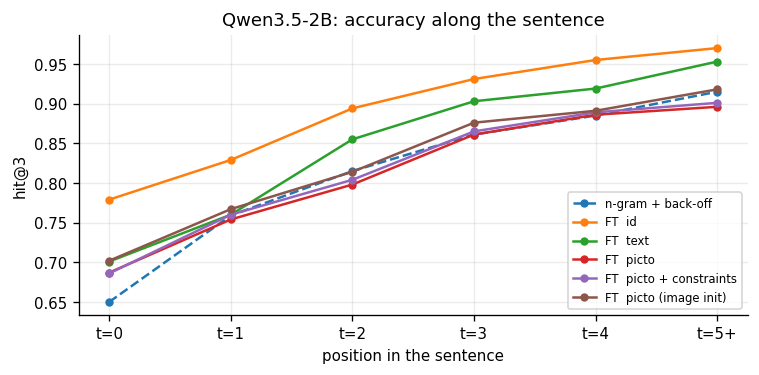

In [36]:
fig, ax = plt.subplots(figsize=(6.4, 3.2))
show = [l for l in BY_STEP.index if l.startswith("FT") or "n-gram" in l]
for label in show:
    row = BY_STEP.loc[label]
    ax.plot(range(len(row)), row.values, marker="o", ms=4, label=label.strip(),
            ls="--" if "n-gram" in label else "-")
ax.set(xlabel="position in the sentence", ylabel=MAIN, title=f"{MODEL}: accuracy along the sentence")
ax.set_xticks(range(BY_STEP.shape[1]), BY_STEP.columns)
ax.legend(fontsize=7)
plt.tight_layout(); plt.savefig(FIGURES / "03_by_step.png", bbox_inches="tight"); plt.show()

### 4.4 The metadata split

All steps, and the easier subset where the gold pictogram has a description.

In [37]:
rows = {}
for label, recs in RUNS.items():
    for name, which in [("all", "all"), ("has description", "has_description"),
                        ("NO description", "no_description")]:
        m = compute(subset(recs, which), corpus.equivalence)
        if m.get("n"):
            rows.setdefault(label, {})[name] = round(m[MAIN], 3)
            rows[label][f"{name} (n)"] = m["n"]
BY_META = pd.DataFrame(rows).T
BY_META[["all", "has description", "NO description"]]

,all,has description,NO description
random pick,0.365,0.369,0.336
frequency prior,0.774,0.786,0.681
n-gram + back-off,0.782,0.792,0.704
FT id,0.867,0.856,0.957
FT text,0.815,0.840,0.622
FT picto,0.785,0.806,0.624
FT picto + constraints,0.789,0.808,0.643
FT picto (image init),0.799,0.807,0.734


## 5. Vision: picto tokens initialised from the image

For pictograms without a description the text initialisation falls back to
random. The image initialisation uses the model's own vision encoder instead.

In [38]:
rows = {}
for tag in MODELS:
    for init in ("text", "image"):
        recs = load(f"picto_{init}_{tag}")
        if not recs:
            continue
        for which in ("has_description", "no_description"):
            m = compute(subset(recs, which), corpus.equivalence)
            rows.setdefault(f"{tag}, {init} init", {})[which] = round(m[MAIN], 3)
VISION = pd.DataFrame(rows).T
VISION

,has_description,no_description
"LFM2.5-350M, text init",0.806,0.587
"Qwen3.5-0.8B, text init",0.804,0.593
"Qwen3.5-0.8B, image init",0.805,0.735
"Qwen3.5-2B, text init",0.806,0.624
"Qwen3.5-2B, image init",0.807,0.734


## 6. Constrained decoding

A prefix tree records which pictograms followed which; candidates outside it are
suppressed. The study re-ranks the saved scores, so it costs no GPU time, and
reports hit@1 (first choice). The second sweep adds a growing share of the test
sentences to the tree on purpose, to see how the gain grows with coverage.

In [39]:
# One table per sweep, on the picto run of Qwen3.5-2B
study = json.loads((RESULTS / "constraint_study.json").read_text())["runs"]
CS = pd.DataFrame(study["picto_text_Qwen3.5-2B"])
NO_CONSTRAINT = CS.loc[CS["sweep"] == "none", "hit@1"].iloc[0]
print(f"no constraint: hit@1 {NO_CONSTRAINT:.3f}")

# Trie built from a share of the training data only
CS[CS["sweep"] == "train"].set_index("setting")[["hit@1", "gold_removed"]].round(3)

no constraint: hit@1 0.392


,hit@1,gold_removed
setting,,
10% of non-test data,0.400,0.174
25% of non-test data,0.401,0.187
50% of non-test data,0.403,0.194
100% of non-test data,0.407,0.195


In [40]:
# Trie built from all training data plus a share of the test sentences (5 random orders).
# covered / uncovered: steps whose sentence is / is not in the trie ("-" when there are none)
TEST_SWEEP = CS[CS["sweep"] == "test"].set_index("setting")[
    ["hit@1", "hit@1_sd", "hit@1_covered", "hit@1_uncovered", "gold_removed"]]
TEST_SWEEP.round(3).fillna("-")

,hit@1,hit@1_sd,hit@1_covered,hit@1_uncovered,gold_removed
setting,,,,,
non-test + 0% of test,0.407,0.000,-,0.407,0.195
non-test + 10% of test,0.436,0.001,0.699,0.407,0.175
non-test + 25% of test,0.480,0.003,0.701,0.407,0.146
non-test + 50% of test,0.555,0.002,0.705,0.406,0.096
non-test + 75% of test,0.632,0.002,0.707,0.406,0.047
non-test + 100% of test,0.709,0.000,0.709,-,0.000


In [41]:
# Soft prior: a bonus lambda for allowed candidates instead of a hard mask
CS[CS["sweep"] == "soft"].set_index("setting")[["hit@1"]].round(3)

,hit@1
setting,
soft prior lambda=0.25,0.394
soft prior lambda=0.5,0.395
soft prior lambda=1.0,0.396
soft prior lambda=2.0,0.398
soft prior lambda=5.0,0.398


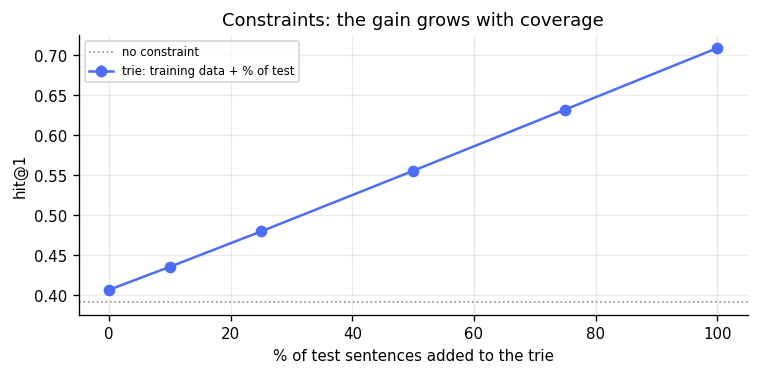

In [42]:
test = CS[CS["sweep"] == "test"]
fig, ax = plt.subplots(figsize=(6.4, 3.2))
ax.errorbar(test["fraction"] * 100, test["hit@1"], yerr=test["hit@1_sd"], marker="o",
            color=BLUE, label="trie: training data + % of test")
ax.axhline(NO_CONSTRAINT, color=GREY, ls=":", lw=1, label="no constraint")
ax.set(xlabel="% of test sentences added to the trie", ylabel="hit@1",
       title="Constraints: the gain grows with coverage")
ax.legend(fontsize=7)
plt.tight_layout(); plt.savefig(FIGURES / "05_constraints.png", bbox_inches="tight"); plt.show()

## 7. Training-seed variance

The confidence intervals only cover which test sentences were drawn. Retraining
with another seed measures the other source of noise.

In [43]:
rows = {}
for label, name in [("seed 42", "picto_text_Qwen3.5-0.8B"),
                    ("seed 43", "picto_text_Qwen3.5-0.8B_seed43")]:
    recs = load(name)
    if recs:
        rows[label] = {which: round(compute(subset(recs, which), corpus.equivalence)[MAIN], 3)
                       for which in ["all", "has_description", "no_description"]}
SEEDS = pd.DataFrame(rows).T
if len(SEEDS) == 2:
    SEEDS.loc["difference"] = (SEEDS.iloc[1] - SEEDS.iloc[0]).round(3)
SEEDS

,all,has_description,no_description
seed 42,0.780,0.804,0.593
seed 43,0.784,0.804,0.629
difference,0.004,0.000,0.036


## 8. Error analysis

/home/davide/UNI/bdatm_project/bdatm/.venv/lib/python3.12/site-packages/PIL/Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


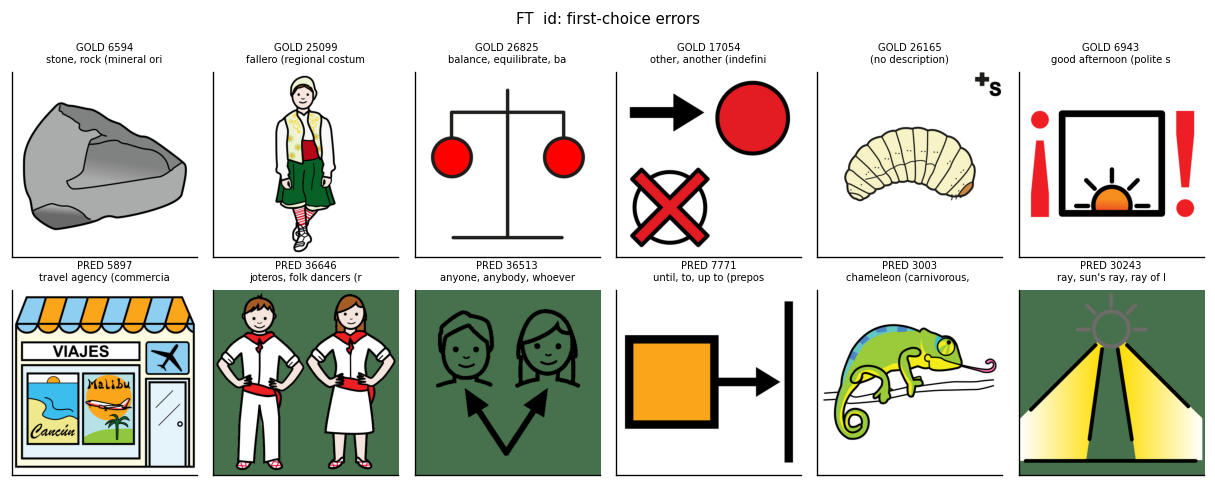

In [44]:
from io import BytesIO
from PIL import Image
from datasets import Image as HFImage
from src.data import _load_hf, PICTOGRAMS_REPO, PICTOGRAMS_REVISION

_IMG = {}
def picto_image(pid):
    if not _IMG:
        ds = _load_hf(PICTOGRAMS_REPO, PICTOGRAMS_REVISION).cast_column("image", HFImage(decode=False))
        for row in ds:
            _IMG[int(row["pictogram_id"])] = row["image"]["bytes"]
    raw = _IMG.get(int(pid))
    return Image.open(BytesIO(raw)).convert("RGB") if raw else None

def show_errors(label, n=6, seed=0):
    recs = [r for r in RUNS[label] if r["ranked_ids"][0] != r["gold_id"]]
    picks = [recs[i] for i in np.random.default_rng(seed).choice(len(recs), n, replace=False)]
    fig, axes = plt.subplots(2, n, figsize=(1.7 * n, 4.2))
    for j, r in enumerate(picks):
        for row, pid in enumerate([r["gold_id"], r["ranked_ids"][0]]):
            a = axes[row, j]
            img = picto_image(pid)
            if img is not None: a.imshow(img)
            a.set_xticks([]); a.set_yticks([])
            a.set_title(("GOLD " if row == 0 else "PRED ") +
                        f"{pid}\n{corpus.description.get(pid,'?')[:24]}", fontsize=6)
    fig.suptitle(f"{label}: first-choice errors", fontsize=9)
    plt.tight_layout(); plt.savefig(FIGURES / "04_errors.png", bbox_inches="tight"); plt.show()

ft = [l for l in RUNS if l.startswith("FT")]
if ft:
    show_errors(max(ft, key=lambda l: compute(RUNS[l], corpus.equivalence)["hit@1"]))

In [45]:
# How many "errors" are near-synonyms the strict metric refuses to credit?
pd.DataFrame({
    label: {
        "strict":  round(compute(subset(r), corpus.equivalence)[MAIN], 3),
        "relaxed": round(compute(subset(r), corpus.equivalence)[f"relaxed_{MAIN}"], 3),
    } for label, r in RUNS.items()
}).T.assign(recovered=lambda d: (d["relaxed"] - d["strict"]).round(3))

,strict,relaxed,recovered
random pick,0.365,0.405,0.040
frequency prior,0.774,0.786,0.012
n-gram + back-off,0.782,0.793,0.011
FT id,0.867,0.880,0.013
FT text,0.815,0.827,0.012
FT picto,0.785,0.794,0.009
FT picto + constraints,0.789,0.798,0.009
FT picto (image init),0.799,0.808,0.009
